<a href="https://colab.research.google.com/github/TatkovDmitriy/-/blob/main/%D0%97%D0%B0%D0%BC%D0%B5%D1%80%D1%8B_%D0%9C%D0%9F4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U -q PyDrive
# 📦 Загрузка библиотек для анализа данных

# Работа с таблицами и массивами
import pandas as pd
import numpy as np
import re
import dateparser
# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
plt.style.use('ggplot')  # безопасная альтернатива, встроенная в matplotlib
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_palette('Set2')

# Статистика и A/B-тесты
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Работа с датами
import datetime as dt
from google.colab import auth
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from oauth2client.client import GoogleCredentials


# Отображение и подавление предупреждений
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
print("библиотеки загружены")


библиотеки загружены


In [2]:
# Авторизация
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Загрузка файла
file_id = '1XfLTkntg4MJwNX4qBq3UneaJdZTRSKaG'
downloaded = drive.CreateFile({'id': file_id})
downloaded.GetContentFile('measurement.csv')

# Чтение файла с корректным разделителем
data = pd.read_csv('measurement.csv', sep=';', encoding='utf-8')

# Удаление полностью пустых столбцов
data = data.dropna(axis=1, how='all')

# Функция для парсинга русских дат с очисткой
def parse_date_ru_cleaned(text):
    if not isinstance(text, str):
        return pd.NaT
    cleaned = re.sub(r'\s+', ' ', text.replace('\xa0', ' ')).strip()
    return dateparser.parse(cleaned, languages=['ru'])

# Список колонок с датами
# Добавим колонку "Дата создания сделки" к преобразованию
date_columns = [
    'Дата создания лида',
    'Дата создания замера',
    'Просрочка',
    'Дата выполнения',
    'Дата создания сделки'  # добавлено!
]

# Преобразуем к datetime
for col in date_columns:
    if col in data.columns:
        data[col] = data[col].apply(parse_date_ru_cleaned)


# Выводим результат
print("✅ Данные успешно загружены и обработаны.")
print("🔍 Preview:")
display(data.head())

print("ℹ️ Информация о типах данных:")
display(data.info())

✅ Данные успешно загружены и обработаны.
🔍 Preview:


,Дата создания лида,Телефон,Ответственный,Проектный мир,Статус лида,Статус сделки,GMV,Дата создания сделки,Комментарий СППО,Номер замера,Статус замера,Дата создания замера,Просрочка,Дата выполнения
0,2025-07-05 18:12:00,7 910 633-91-85,ОДП,Входные двери,Сделка создана,Отменена,NaN,2025-07-05,"Прочее у клиента уже все оформлено, в магазине...",5467392,выполнен,2025-06-30,NaT,2025-06-30
1,2025-07-05 17:41:00,7 950 842-14-90,ОДП,Входные двери,Сделка создана,Активна,NaN,2025-07-05,контроль ответа клиента,5438686,выполнен,2025-06-23,2025-06-26,2025-06-29
2,2025-07-03 19:23:00,7 919 847-46-55,ОДП,Входные двери,Сделка создана,Активна,1000.0,2025-07-03,контроль ответа клиента,5430048,выполнен,2025-06-21,NaT,2025-06-24
3,2025-06-21 18:04:00,7 905 074-86-74,ОДП,Входные двери,Сделка создана,Отменена,NaN,2025-07-21,Заказ оформлен 250673466575,5410115,выполнен,2025-06-15,NaT,2025-06-16
4,2025-06-18 20:03:00,7 911 952-50-62,ОДП,Входные двери,Сделка создана,Отменена,NaN,2025-06-18,не актуально,5395252,выполнен,2025-06-12,NaT,2025-06-12


ℹ️ Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Дата создания лида    373 non-null    datetime64[ns]
 1   Телефон               373 non-null    object        
 2   Ответственный         335 non-null    object        
 3   Проектный мир         373 non-null    object        
 4   Статус лида           373 non-null    object        
 5   Статус сделки         372 non-null    object        
 6   GMV                   185 non-null    float64       
 7   Дата создания сделки  329 non-null    datetime64[ns]
 8   Комментарий СППО      286 non-null    object        
 9   Номер замера          373 non-null    object        
 10  Статус замера         373 non-null    object        
 11  Дата создания замера  373 non-null    datetime64[ns]
 12  Просрочка             125 non-null    datetime64

None

## 📊 Описание данных

Анализируем лиды, созданные после оплаченных онлайн-замеров за период **с 01.06.2025 по 05.07.2025**. Ниже представлено описание всех столбцов датасета:

- **Дата создания лида** — дата создания лида в отдел дистанционных продаж (ОДП). Лид создаётся только после выполнения и оплаты замера.
- **Телефон** — номер телефона клиента, на который был создан лид.
- **Ответственный** — канал сопровождения сделки:
  - `ОДП` — отдел дистанционных продаж,
  - `Магазин` — офлайн-магазин.
- **Проектный мир** — категория проекта, по которой был оформлен замер. Возможные значения:
  - `Двери`,
  - `Кухни`,
  - `Хранение`,
  - `Ванные`.
- **Статус лида** — текущий статус лида:
  - `Сделка создана` — из лида была создана сделка,
  - `Отменена` — лид сразу отменили, сделку из него не создавали.
- **Статус сделки** — финальный статус сделки клиента. Может быть заполнен даже если лид отменён (например, если сделка была создана ранее или параллельно).
- **GMV** — сумма оплаты по сделке:
  - `> 5000` — оплата за товар или услуги,
  - `< 5000` — только замер, без покупки.
- **Дата создания сделки** — дата, когда была создана сделка.
- **Комментарий СППО** — комментарии сотрудников CRM по лидам и сделкам.
- **Номер замера** — идентификатор замера, из которого был создан лид.
- **Статус замера** — статус выполнения замера, например `выполнен`.
- **Дата создания замера** — дата, когда клиент оформил замер онлайн.
- **Просрочка** — если указана дата, значит в этот день началась просрочка выполнения замера; если пусто — замер выполнен в срок.
- **Дата выполнения** — фактическая дата выполнения замера.


In [3]:
# Подготовка
data.columns = data.columns.str.strip()
df_valid = data[data['Дата создания лида'].notna()]

# Считаем лиды по шагам вручную
result = []

for project in df_valid['Проектный мир'].unique():
    df_project = df_valid[df_valid['Проектный мир'] == project]

    # Шаг 1: все лиды
    total_leads = len(df_project)

    # Шаг 2: лиды, по которым создали сделку
    created_deals = df_project[df_project['Статус лида'] == 'Сделка создана']
    count_created_deals = len(created_deals)

    # Шаг 3: среди них — с GMV > 0
    successful_orders = created_deals[created_deals['GMV'] > 0]
    count_successful_orders = len(successful_orders)

    # Шаг 4: среди них — GMV > 5000
    successful_projects = successful_orders[successful_orders['GMV'] > 5000]
    count_successful_projects = len(successful_projects)

    # Расчёт конверсий
    cr1 = round(count_created_deals / total_leads * 100, 1) if total_leads else 0
    cr2 = round(count_successful_orders / count_created_deals * 100, 1) if count_created_deals else 0
    cr3 = round(count_successful_projects / count_successful_orders * 100, 1) if count_successful_orders else 0

    # Сохраняем результат
    result.append({
        'Проектный мир': project,
        'количество лидов': total_leads,
        'количество созданных сделок': count_created_deals,
        'CR1 %': cr1,
        'количество успешных заказов': count_successful_orders,
        'CR2 %': cr2,
        'количество успешных проектов': count_successful_projects,
        'CR3 %': cr3
    })

# Преобразуем в DataFrame
funnel_df = pd.DataFrame(result)

# Выводим
from IPython.display import display
display(funnel_df)


,Проектный мир,количество лидов,количество созданных сделок,CR1 %,количество успешных заказов,CR2 %,количество успешных проектов,CR3 %
0,Входные двери,68,8,11.8,1,12.5,0,0.0
1,Ванная комната,42,32,76.2,28,87.5,13,46.4
2,Хранение,34,7,20.6,5,71.4,4,80.0
3,Кухни,229,16,7.0,8,50.0,2,25.0


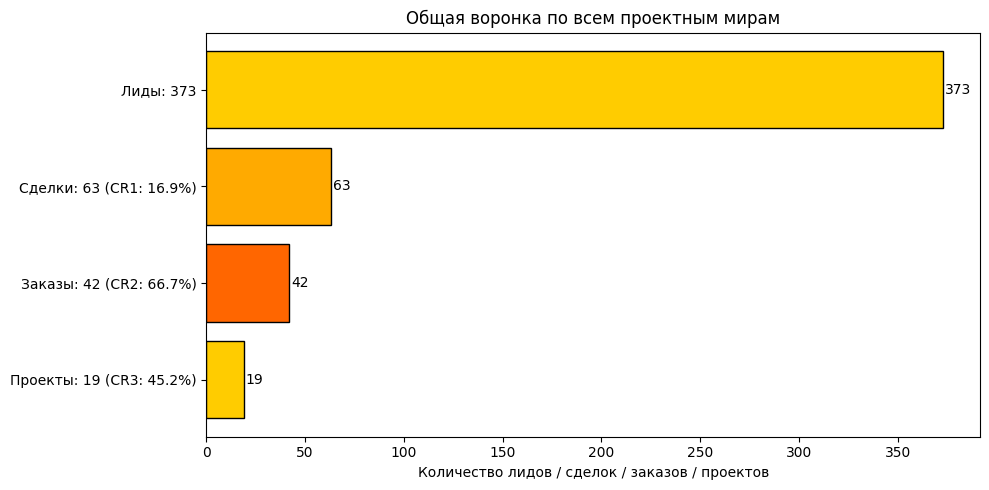

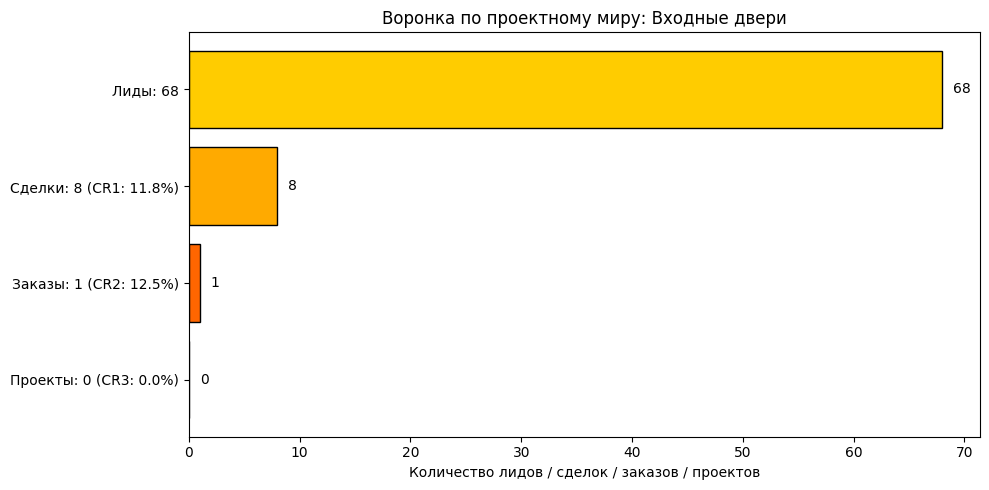

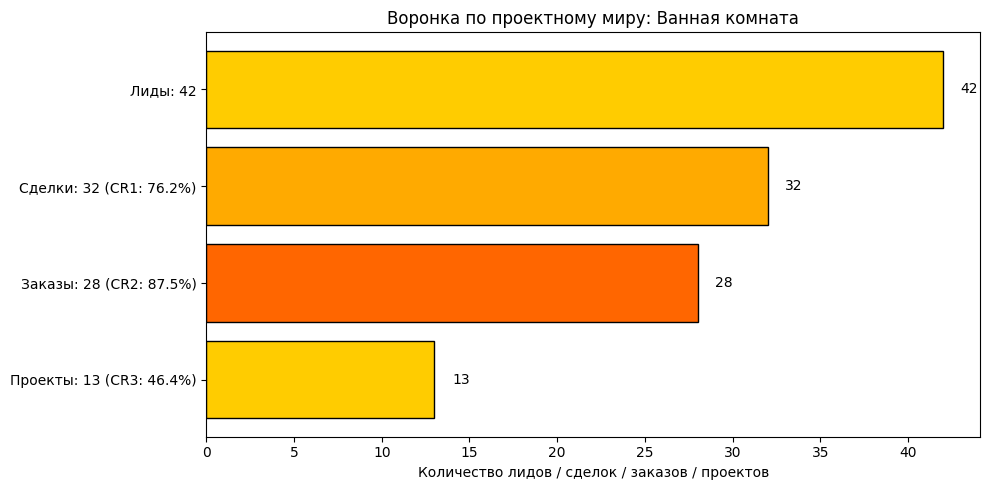

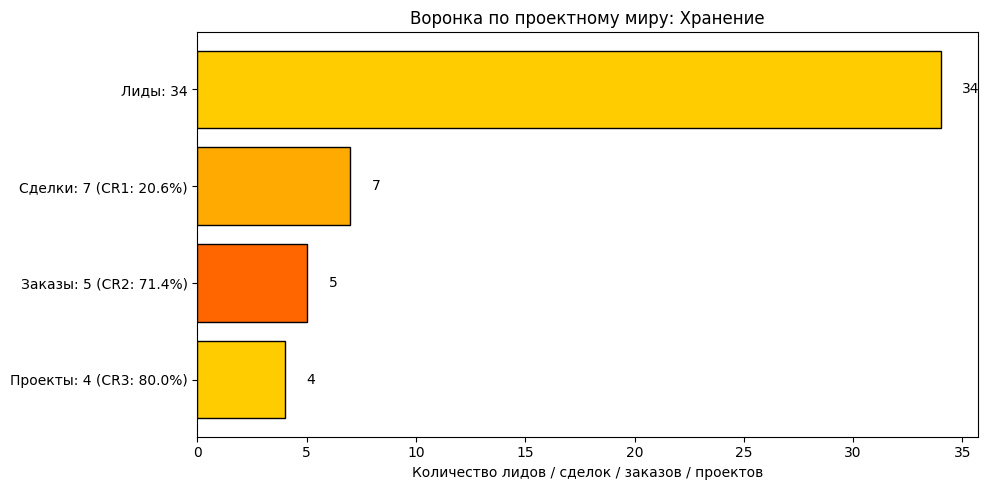

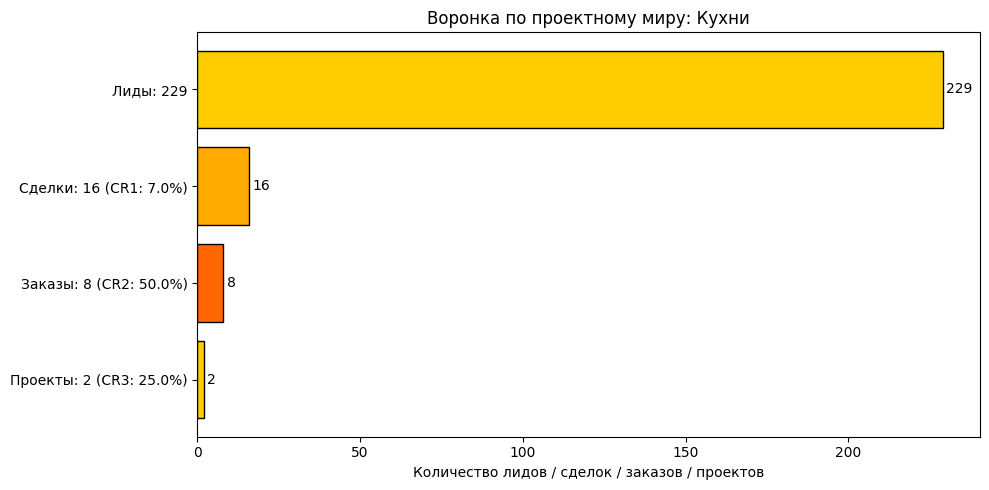

In [4]:

# Стиль графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

# Цвета этапов
colors = ['#ffcc00', '#ffaa00', '#ff6600']

# Общая воронка по всем проектным мирам
total_leads = funnel_df['количество лидов'].sum()
total_created = funnel_df['количество созданных сделок'].sum()
total_orders = funnel_df['количество успешных заказов'].sum()
total_projects = funnel_df['количество успешных проектов'].sum()

cr1 = round(total_created / total_leads * 100, 1) if total_leads else 0
cr2 = round(total_orders / total_created * 100, 1) if total_created else 0
cr3 = round(total_projects / total_orders * 100, 1) if total_orders else 0

total_stages = [total_leads, total_created, total_orders, total_projects]
total_labels = [
    f"Лиды: {total_leads}",
    f"Сделки: {total_created} (CR1: {cr1}%)",
    f"Заказы: {total_orders} (CR2: {cr2}%)",
    f"Проекты: {total_projects} (CR3: {cr3}%)"
]

plt.figure(figsize=(10, 5))
bars = plt.barh(range(len(total_stages)), total_stages, color=colors, edgecolor='black')
plt.yticks(range(len(total_stages)), total_labels)
plt.gca().invert_yaxis()
plt.title("Общая воронка по всем проектным мирам")
plt.xlabel("Количество лидов / сделок / заказов / проектов")

for i, v in enumerate(total_stages):
    plt.text(v + 1, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

# Визуализация по каждому проектному миру
for _, row in funnel_df.iterrows():
    stages = [
        row['количество лидов'],
        row['количество созданных сделок'],
        row['количество успешных заказов'],
        row['количество успешных проектов']
    ]

    labels = [
        f"Лиды: {stages[0]}",
        f"Сделки: {stages[1]} (CR1: {row['CR1 %']}%)",
        f"Заказы: {stages[2]} (CR2: {row['CR2 %']}%)",
        f"Проекты: {stages[3]} (CR3: {row['CR3 %']}%)"
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(range(len(stages)), stages, color=colors, edgecolor='black')
    plt.yticks(range(len(stages)), labels)
    plt.gca().invert_yaxis()
    plt.title(f"Воронка по проектному миру: {row['Проектный мир']}")
    plt.xlabel("Количество лидов / сделок / заказов / проектов")

    for i, v in enumerate(stages):
        plt.text(v + 1, i, str(int(v)), va='center')

    plt.tight_layout()
    plt.show()


In [5]:
# Очистка названий столбцов
data.columns = data.columns.str.strip()

# Только лиды с датой создания
df_valid = data[data['Дата создания лида'].notna()]

# Результаты по шагам
result = []

for project in df_valid['Проектный мир'].unique():
    df_project = df_valid[df_valid['Проектный мир'] == project]

    # Шаг 1: все лиды
    total_leads = len(df_project)

    # Шаг 2: сделки, у которых есть дата создания сделки
    deals_with_date = df_project[df_project['Дата создания сделки'].notna()]
    count_created_deals = len(deals_with_date)

    # Шаг 3: сделки с GMV > 0
    successful_orders = deals_with_date[deals_with_date['GMV'] > 0]
    count_successful_orders = len(successful_orders)

    # Шаг 4: сделки с GMV > 5000
    successful_projects = successful_orders[successful_orders['GMV'] > 5000]
    count_successful_projects = len(successful_projects)

    # Конверсии
    cr1 = round(count_created_deals / total_leads * 100, 1) if total_leads else 0
    cr2 = round(count_successful_orders / count_created_deals * 100, 1) if count_created_deals else 0
    cr3 = round(count_successful_projects / count_successful_orders * 100, 1) if count_successful_orders else 0

    # Добавление в результат
    result.append({
        'Проектный мир': project,
        'количество лидов': total_leads,
        'количество созданных сделок': count_created_deals,
        'CR1 %': cr1,
        'количество успешных заказов': count_successful_orders,
        'CR2 %': cr2,
        'количество успешных проектов': count_successful_projects,
        'CR3 %': cr3
    })

# Таблица
funnel_df_2 = pd.DataFrame(result)

# Вывод
from IPython.display import display
display(funnel_df_2)


,Проектный мир,количество лидов,количество созданных сделок,CR1 %,количество успешных заказов,CR2 %,количество успешных проектов,CR3 %
0,Входные двери,68,61,89.7,37,60.7,34,91.9
1,Ванная комната,42,42,100.0,34,81.0,18,52.9
2,Хранение,34,31,91.2,20,64.5,19,95.0
3,Кухни,229,195,85.2,93,47.7,86,92.5


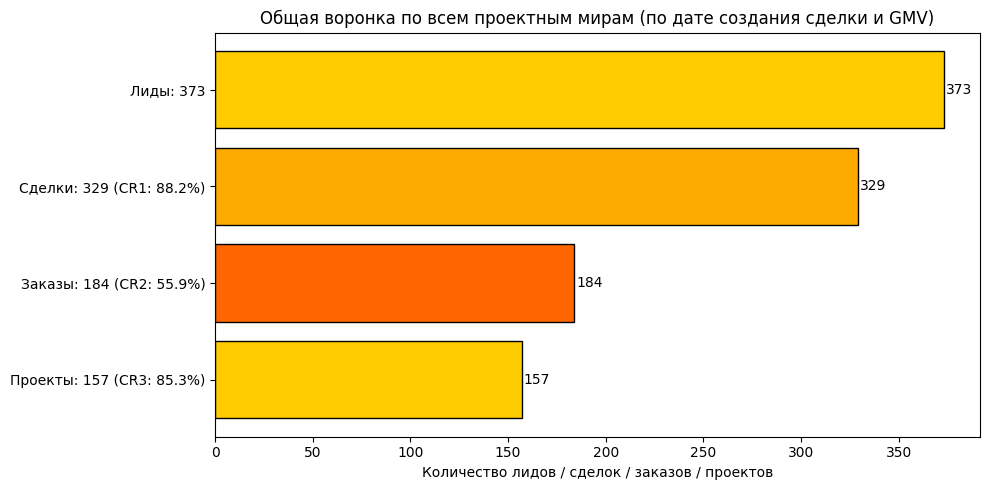

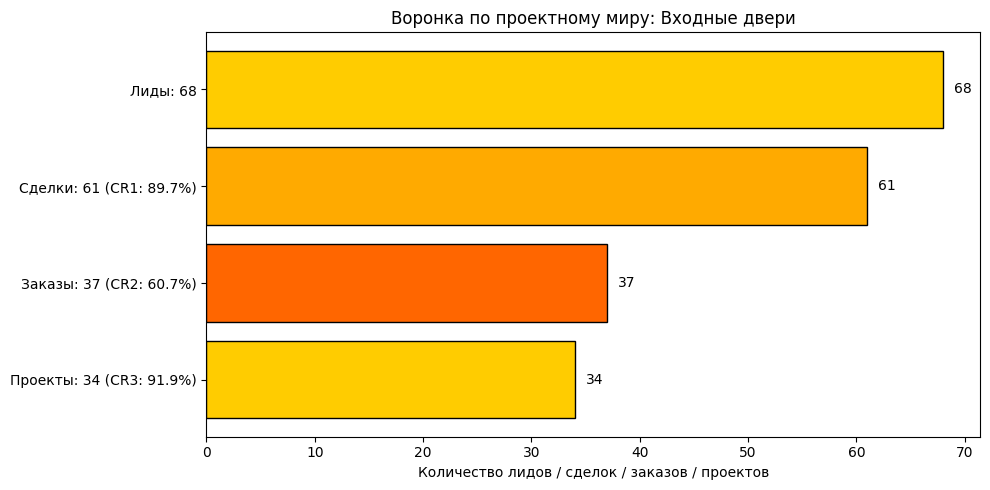

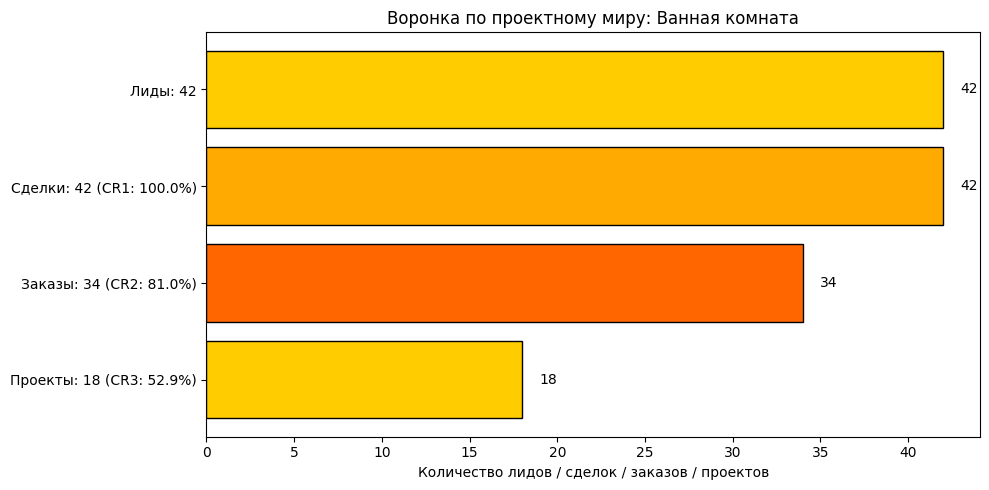

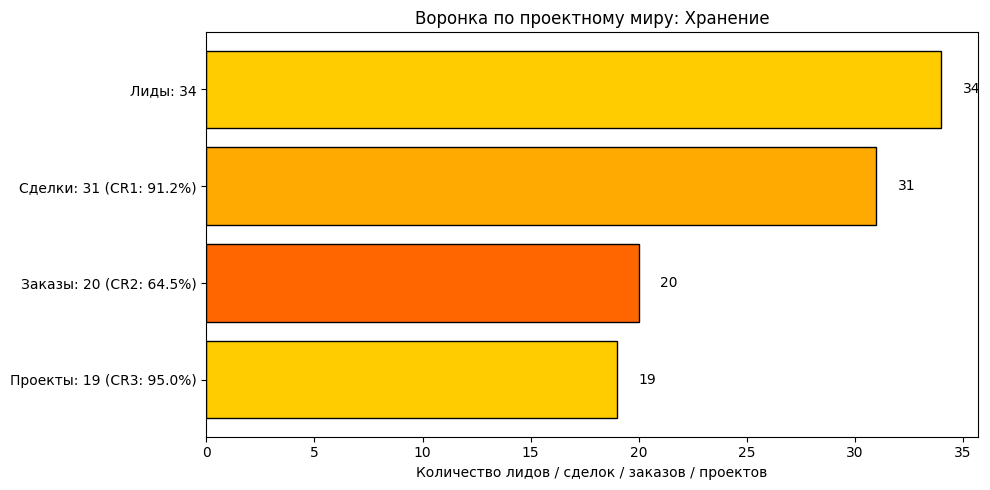

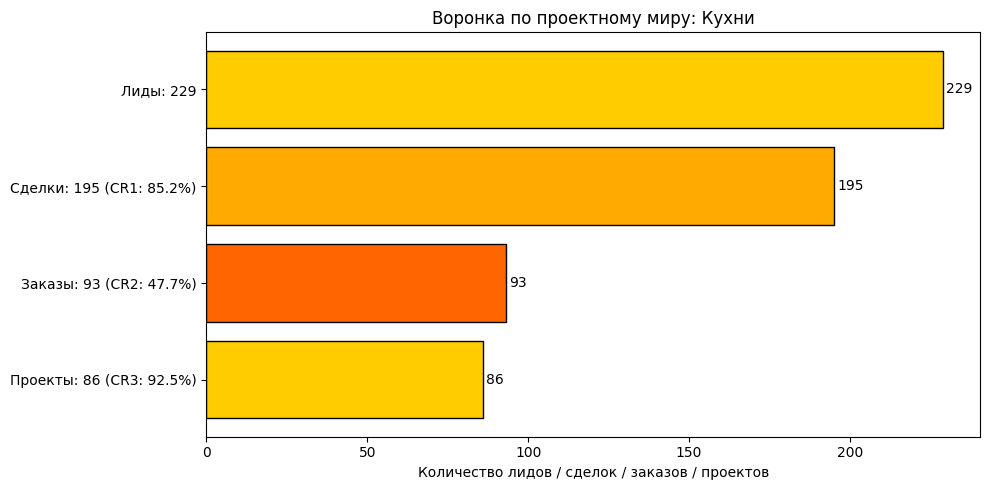

In [6]:
# Стиль графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

# Цвета этапов
colors = ['#ffcc00', '#ffaa00', '#ff6600']

# Общая воронка по всем проектным мирам (по funnel_df_2)
total_leads = funnel_df_2['количество лидов'].sum()
total_created = funnel_df_2['количество созданных сделок'].sum()
total_orders = funnel_df_2['количество успешных заказов'].sum()
total_projects = funnel_df_2['количество успешных проектов'].sum()

cr1 = round(total_created / total_leads * 100, 1) if total_leads else 0
cr2 = round(total_orders / total_created * 100, 1) if total_created else 0
cr3 = round(total_projects / total_orders * 100, 1) if total_orders else 0

total_stages = [total_leads, total_created, total_orders, total_projects]
total_labels = [
    f"Лиды: {total_leads}",
    f"Сделки: {total_created} (CR1: {cr1}%)",
    f"Заказы: {total_orders} (CR2: {cr2}%)",
    f"Проекты: {total_projects} (CR3: {cr3}%)"
]

plt.figure(figsize=(10, 5))
bars = plt.barh(range(len(total_stages)), total_stages, color=colors, edgecolor='black')
plt.yticks(range(len(total_stages)), total_labels)
plt.gca().invert_yaxis()
plt.title("Общая воронка по всем проектным мирам (по дате создания сделки и GMV)")
plt.xlabel("Количество лидов / сделок / заказов / проектов")

for i, v in enumerate(total_stages):
    plt.text(v + 1, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

# Визуализация по каждому проектному миру
for _, row in funnel_df_2.iterrows():
    stages = [
        row['количество лидов'],
        row['количество созданных сделок'],
        row['количество успешных заказов'],
        row['количество успешных проектов']
    ]

    labels = [
        f"Лиды: {stages[0]}",
        f"Сделки: {stages[1]} (CR1: {row['CR1 %']}%)",
        f"Заказы: {stages[2]} (CR2: {row['CR2 %']}%)",
        f"Проекты: {stages[3]} (CR3: {row['CR3 %']}%)"
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(range(len(stages)), stages, color=colors, edgecolor='black')
    plt.yticks(range(len(stages)), labels)
    plt.gca().invert_yaxis()
    plt.title(f"Воронка по проектному миру: {row['Проектный мир']}")
    plt.xlabel("Количество лидов / сделок / заказов / проектов")

    for i, v in enumerate(stages):
        plt.text(v + 1, i, str(int(v)), va='center')

    plt.tight_layout()
    plt.show()


In [7]:
# Подготовка
data.columns = data.columns.str.strip()
df_valid = data[data['Дата создания сделки'].notna()]

# Группировка по проектному миру и ответственному
pivot_table = df_valid.groupby(['Проектный мир', 'Ответственный']).size().unstack(fill_value=0)

# Переименуем столбцы для ясности
pivot_table.columns = ['Количество сделок: Магазин' if c.lower() == 'магазин' else 'Количество сделок: ОДП' for c in pivot_table.columns]

# Преобразуем в DataFrame для визуализации
pivot_table = pivot_table.reset_index()

# Выводим таблицу
from IPython.display import display
display(pivot_table)


,Проектный мир,Количество сделок: Магазин,Количество сделок: ОДП
0,Ванная комната,26,16
1,Входные двери,18,43
2,Кухни,159,36
3,Хранение,26,5


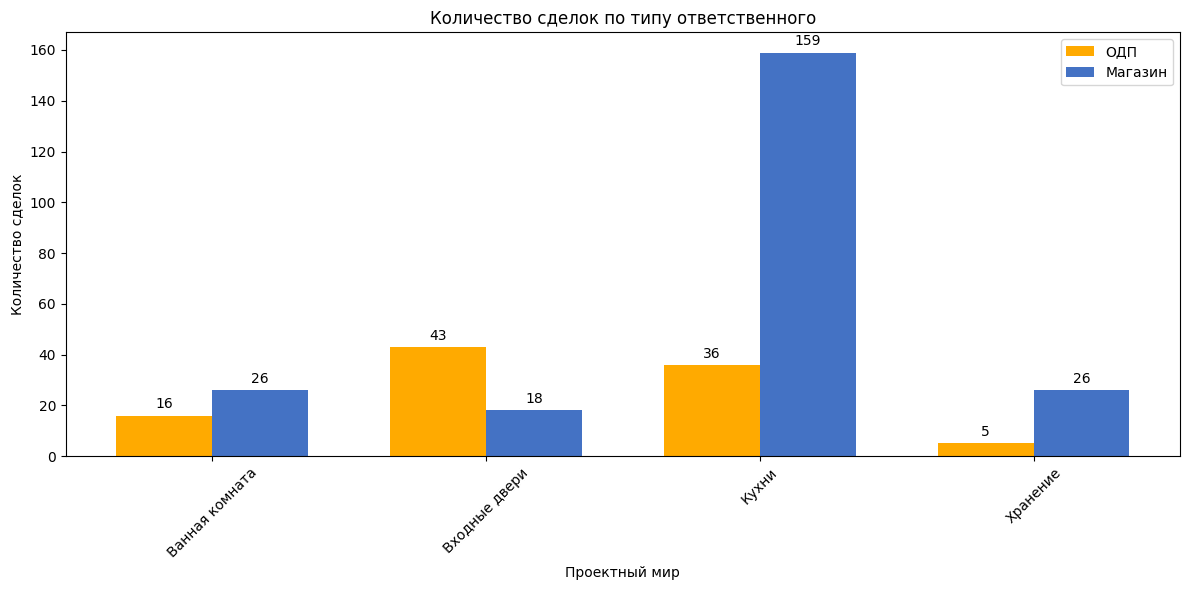

In [8]:

# Значения
labels = pivot_table['Проектный мир']
odp_values = pivot_table['Количество сделок: ОДП'] if 'Количество сделок: ОДП' in pivot_table.columns else [0]*len(labels)
mag_values = pivot_table['Количество сделок: Магазин'] if 'Количество сделок: Магазин' in pivot_table.columns else [0]*len(labels)

x = np.arange(len(labels))  # позиции по X
width = 0.35  # ширина столбца

# График
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, odp_values, width, label='ОДП', color='#ffaa00')
bars2 = ax.bar(x + width/2, mag_values, width, label='Магазин', color='#4472c4')

# Подписи
ax.set_xlabel('Проектный мир')
ax.set_ylabel('Количество сделок')
ax.set_title('Количество сделок по типу ответственного')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

# Значения над столбцами
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # смещение вверх
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [9]:
# Подготовка
data.columns = data.columns.str.strip()

# Фильтруем только успешные проекты (GMV > 5000 и сделка создана)
df_success = data[(data['Дата создания сделки'].notna()) & (data['GMV'] > 5000)]

# Группировка по проектному миру и ответственному
pivot_success = df_success.groupby(['Проектный мир', 'Ответственный']).size().unstack(fill_value=0)

# Переименуем столбцы
pivot_success.columns = ['Успешные проекты: Магазин' if c.lower() == 'магазин' else 'Успешные проекты: ОДП' for c in pivot_success.columns]

# Преобразуем в DataFrame
pivot_success = pivot_success.reset_index()

# Вывод таблицы
from IPython.display import display
display(pivot_success)


,Проектный мир,Успешные проекты: Магазин,Успешные проекты: ОДП
0,Ванная комната,13,5
1,Входные двери,15,19
2,Кухни,81,5
3,Хранение,17,2


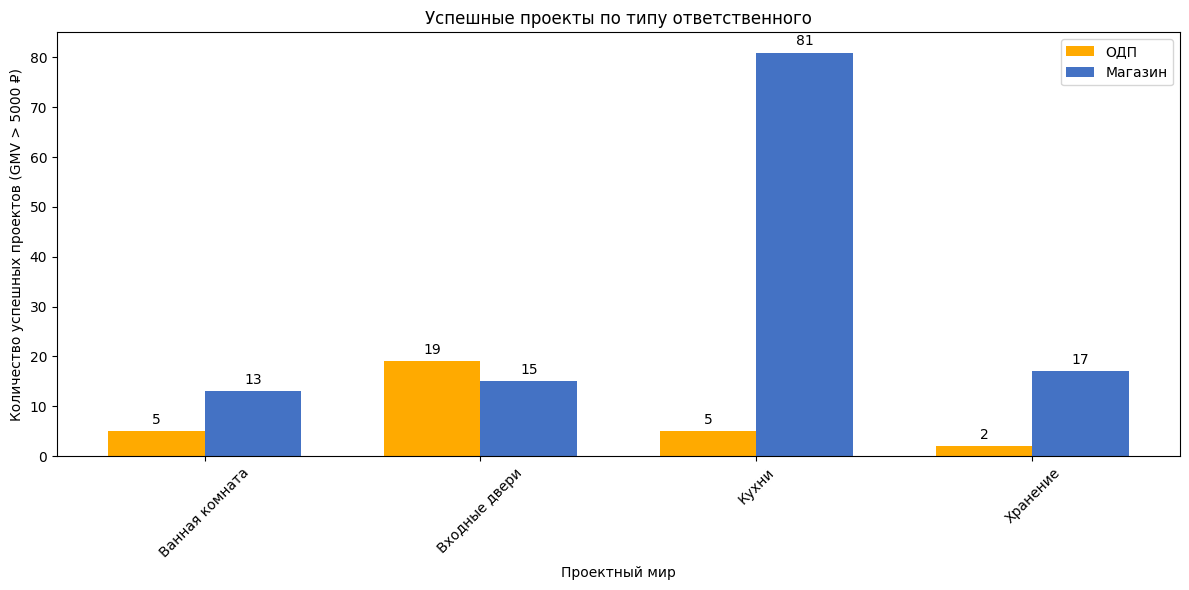

In [10]:
# Значения
labels = pivot_success['Проектный мир']
odp_values = pivot_success['Успешные проекты: ОДП'] if 'Успешные проекты: ОДП' in pivot_success.columns else [0]*len(labels)
mag_values = pivot_success['Успешные проекты: Магазин'] if 'Успешные проекты: Магазин' in pivot_success.columns else [0]*len(labels)

x = np.arange(len(labels))
width = 0.35

# График
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, odp_values, width, label='ОДП', color='#ffaa00')
bars2 = ax.bar(x + width/2, mag_values, width, label='Магазин', color='#4472c4')

# Подписи
ax.set_xlabel('Проектный мир')
ax.set_ylabel('Количество успешных проектов (GMV > 5000 ₽)')
ax.set_title('Успешные проекты по типу ответственного')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

# Подписи над столбцами
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [11]:


# Убедимся, что датафрейм в порядке
data.columns = data.columns.str.strip()

# Только строки, где замер был выполнен
df_done = data[data['Дата выполнения'].notna() & data['Дата создания замера'].notna()]

# Создаём вспомогательные колонки
df_done['есть_просрочка'] = df_done['Просрочка'].notna()
df_done['длительность_просрочки'] = (df_done['Дата выполнения'] - df_done['Просрочка']).dt.days
df_done['время_до_выполнения'] = (df_done['Дата выполнения'] - df_done['Дата создания замера']).dt.days

# Группировка по проектному миру
result = df_done.groupby('Проектный мир').agg(
    всего_замеров=('есть_просрочка', 'count'),
    просроченных_замеров=('есть_просрочка', 'sum'),
    средняя_просрочка=('длительность_просрочки', 'mean'),
    среднее_время_до_выполнения=('время_до_выполнения', 'mean')
).reset_index()

# Добавляем % просроченных
result['% просроченных замеров'] = round(result['просроченных_замеров'] / result['всего_замеров'] * 100, 1)

# Приводим значения к целым дням
result['средняя_просрочка'] = result['средняя_просрочка'].round(1)
result['среднее_время_до_выполнения'] = result['среднее_время_до_выполнения'].round(1)

# Вывод

display(result[['Проектный мир', '% просроченных замеров', 'средняя_просрочка', 'среднее_время_до_выполнения']])


,Проектный мир,% просроченных замеров,средняя_просрочка,среднее_время_до_выполнения
0,Ванная комната,72.5,1.7,4.6
1,Входные двери,30.8,1.0,2.0
2,Кухни,30.3,1.2,2.8
3,Хранение,24.2,0.2,2.4


In [12]:
# Отбираем строки с обеими датами
df_with_dates = data[data['Дата создания замера'].notna() & data['Дата создания сделки'].notna()]

# Сравниваем даты
df_with_dates['замер_до_сделки'] = df_with_dates['Дата создания замера'] < df_with_dates['Дата создания сделки']

# Подсчёты
total_rows = len(df_with_dates)
count_before = df_with_dates['замер_до_сделки'].sum()
percent_before = round(count_before / total_rows * 100, 1) if total_rows else 0

# Вывод
print(f"🔍 Всего строк с обеими датами: {total_rows}")
print(f"📌 Количество замеров, созданных ДО даты создания сделки: {count_before}")
print(f"📊 Доля таких случаев: {percent_before}%")


🔍 Всего строк с обеими датами: 329
📌 Количество замеров, созданных ДО даты создания сделки: 256
📊 Доля таких случаев: 77.8%


In [19]:
# Отбираем строки с обеими датами
df_with_dates = data[data['Дата создания замера'].notna() & data['Дата создания сделки'].notna()].copy()

# Вычисляем разницу в днях между замером и сделкой
df_with_dates['разница_дней'] = (df_with_dates['Дата создания замера'] - df_with_dates['Дата создания сделки']).dt.days

# Признак: замер создан до сделки
df_with_dates['замер_до_сделки'] = df_with_dates['Дата создания замера'] < df_with_dates['Дата создания сделки']


# Группировка по проектному миру
result_by_project = df_with_dates.groupby('Проектный мир').agg(
    всего_строк=('разница_дней', 'count'),
    замеров_до_сделки=('замер_до_сделки', 'sum')
).reset_index()

# Добавляем процент
result_by_project['доля_замеров_до_сделки_%'] = round(
    result_by_project['замеров_до_сделки'] / result_by_project['всего_строк'] * 100, 1
)

# Вывод
from IPython.display import display
display(result_by_project)


,Проектный мир,всего_строк,замеров_до_сделки,доля_замеров_до_сделки_%
0,Ванная комната,42,38,90.5
1,Входные двери,61,60,98.4
2,Кухни,195,134,68.7
3,Хранение,31,24,77.4


In [28]:
# Убедимся, что 'тип' и 'Проектный мир' — категориальные переменные
df_with_dates['тип'] = df_with_dates['тип'].astype('category')
df_with_dates['Проектный мир'] = df_with_dates['Проектный мир'].astype('category')

# Группировка с учётом всех комбинаций (даже если нет данных)
grouped = df_with_dates.groupby(
    ['Проектный мир', 'тип'], dropna=False, observed=False
)['разница_дней'].mean().round(1).reset_index()

display(grouped)


,Проектный мир,тип,разница_дней
0,Ванная комната,замер до сделки,6.4
1,Ванная комната,замер после сделки,NaN
2,Входные двери,замер до сделки,3.7
3,Входные двери,замер после сделки,-4.0
4,Кухни,замер до сделки,7.6
5,Кухни,замер после сделки,-70.7
6,Хранение,замер до сделки,6.4
7,Хранение,замер после сделки,-27.8


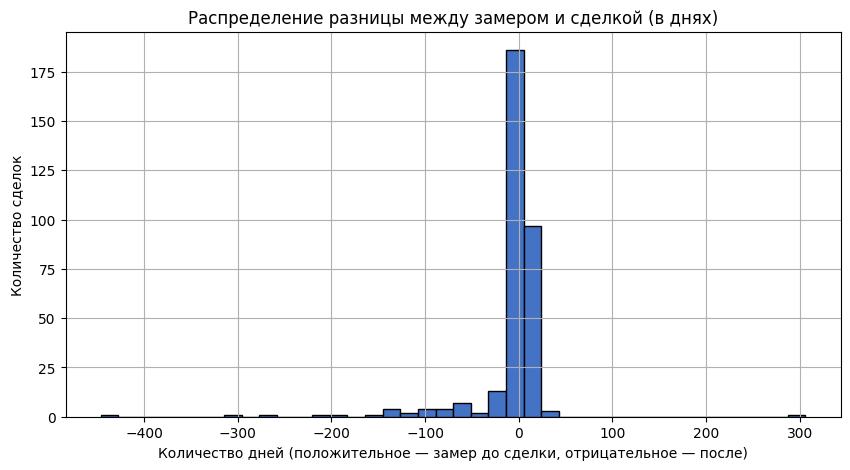

In [15]:

# Гистограмма разницы в днях (всех направлений)
plt.figure(figsize=(10, 5))
df_with_dates['разница_дней'].hist(bins=40, color='#4472c4', edgecolor='black')
plt.title("Распределение разницы между замером и сделкой (в днях)")
plt.xlabel("Количество дней (положительное — замер до сделки, отрицательное — после)")
plt.ylabel("Количество сделок")
plt.grid(True)
plt.show()


In [29]:
# Вычислим 99-й перцентиль по абсолютному значению разницы
q99 = df_with_dates['разница_дней'].abs().quantile(0.95)

# Отфильтруем выбросы
df_filtered = df_with_dates[df_with_dates['разница_дней'].abs() <= q99].copy()

# Пересоздаём колонку 'тип' после фильтрации
df_filtered['тип'] = df_filtered['разница_дней'].apply(
    lambda x: 'замер до сделки' if x >= 0 else 'замер после сделки'
)

# Группировка
grouped_filtered = df_filtered.groupby(['Проектный мир', 'тип'])['разница_дней'].mean().round(1).reset_index()

# Вывод
from IPython.display import display
display(grouped_filtered)


,Проектный мир,тип,разница_дней
0,Ванная комната,замер до сделки,6.4
1,Ванная комната,замер после сделки,NaN
2,Входные двери,замер до сделки,3.7
3,Входные двери,замер после сделки,-4.0
4,Кухни,замер до сделки,5.5
5,Кухни,замер после сделки,-28.1
6,Хранение,замер до сделки,6.4
7,Хранение,замер после сделки,-27.8


In [23]:
# Вычислим 99-й перцентиль по абсолютной разнице
q99 = df_with_dates['разница_дней'].abs().quantile(0.90)

# Фильтрация выбросов
df_outliers = df_with_dates[df_with_dates['разница_дней'].abs() > q99]

# Вывод номеров замеров с выбросами
outlier_measurements = df_outliers[['Номер замера', 'Проектный мир', 'Дата создания замера', 'Дата создания сделки', 'разница_дней']]

# Сортируем по убыванию абсолютной разницы
outlier_measurements = outlier_measurements.reindex(outlier_measurements['разница_дней'].abs().sort_values(ascending=False).index)

# Отображаем таблицу
from IPython.display import display
display(outlier_measurements)


,Номер замера,Проектный мир,Дата создания замера,Дата создания сделки,разница_дней
168,5462433,Кухни,2025-06-29,2024-04-09,-446
176,5451735,Кухни,2025-06-26,2024-08-22,-308
303,5408894,Кухни,2025-06-15,2026-04-17,306
173,5450710,Кухни,2025-06-26,2024-09-28,-271
265,5426805,Кухни,2025-06-20,2024-11-27,-205
266,5424313,Кухни,2025-06-19,2024-12-14,-187
238,5422693,Кухни,2025-06-19,2025-01-24,-146
359,5357503,Кухни,2025-06-02,2025-01-15,-138
146,5434111,Кухни,2025-06-21,2025-02-04,-137
226,5352839,Кухни,2025-05-31,2025-01-19,-132


# ⏱ Среднее количество дней между созданием замера и сделки  
*С учётом фильтрации выбросов по 95-му перцентилю (по абсолютному значению)*

| Проектный мир     | Тип                 | Среднее количество дней |
|-------------------|---------------------|--------------------------|
| Ванная комната    | замер до сделки     | 6.4                      |
| Входные двери     | замер до сделки     | 3.7                      |
| Входные двери     | замер после сделки  | -4.0                     |
| Кухни             | замер до сделки     | 5.5                      |
| Кухни             | замер после сделки  | -28.1                    |
| Хранение          | замер до сделки     | 6.4                      |
| Хранение          | замер после сделки  | -27.8                    |

## 📌 Выводы:

- В большинстве случаев замеры создаются **до** сделок, и среднее время между событиями составляет **3–6 дней**, в зависимости от проектного мира.
- Однако присутствуют и случаи, когда замер оформлен **после** сделки — особенно в категориях **Кухни** и **Хранение**, где среднее значение разницы составляет **-27...-28 дней**.
- Это может указывать на:
  - особенности процесса (например, переоформление замеров после сделки),
  - ошибки в данных (например, ручное вмешательство в даты).
- Рекомендуется проверить корректность дат замеров в этих сегментах, особенно для кухонь.
